# APRENDIZAJE AUTOMÁTICO
# Práctica 4: Regresión Logística Multiclase y Redes Neuronales
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 27-02-2026
---

---
## 0. Carga de datos de MNIST

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load data from https://www.openml.org/
dataset = "mnist_784"
X, y = fetch_openml(dataset, version=1, return_X_y=True, as_frame=False, parser="pandas")
X = X / 255.0  # Escalar los datos entre 0 y 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, shuffle=False)

print('X_train.shape:', X_train.shape)
print('y_train.shape:', y_train.shape)
print('X_test.shape:', X_test.shape)
print('y_test.shape:', y_test.shape)


X_train.shape: (60000, 784)
y_train.shape: (60000,)
X_test.shape: (10000, 784)
y_test.shape: (10000,)


.......

## 1. Curvas de aprendizaje

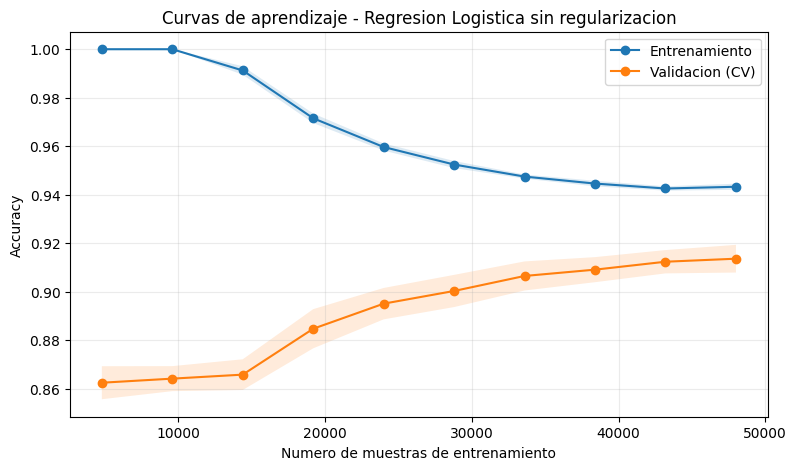

Tamanos evaluados: [ 4800  9600 14400 19200 24000 28800 33600 38400 43200 48000]
Accuracy media entrenamiento: [1.     1.     0.9912 0.9715 0.9597 0.9525 0.9475 0.9446 0.9426 0.9433]
Accuracy media validacion: [0.8626 0.8642 0.8659 0.8848 0.8951 0.9004 0.9066 0.9092 0.9124 0.9137]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold, learning_curve
import matplotlib.pyplot as plt

logit_basico = LogisticRegression(
    penalty=None,            # Sin regularizacion
    max_iter=300,
    random_state=28,
)

train_sizes = np.linspace(0.1, 1.0, 10)

sizes, train_scores, val_scores = learning_curve(estimator=logit_basico, X=X_train, y=y_train, train_sizes=train_sizes,
    cv=5, scoring="accuracy", n_jobs=-1)
LearningCurveDisplay(logit_basico, train_sizes=sizes, train_scores=train_scores, val_scores=val_scores).plot()

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Gráficas generadas con inteligencia artificial.

# plt.figure(figsize=(9, 5))
# plt.plot(sizes, train_mean, "o-", label="Entrenamiento")
# plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
# plt.plot(sizes, val_mean, "o-", label="Validacion (CV)")
# plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
# plt.xlabel("Numero de muestras de entrenamiento")
# plt.ylabel("Accuracy")
# plt.title("Curvas de aprendizaje - Regresion Logistica sin regularizacion")
# plt.grid(alpha=0.25)
# plt.legend()
# plt.show()

print("Tamanos evaluados:", sizes.astype(int))
print("Accuracy media entrenamiento:", np.round(train_mean, 4))
print("Accuracy media validacion:", np.round(val_mean, 4))

## 2. Regresión logística.

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

Cs = np.logspace(-2, 6, 5)
Cs = [0.01, 1, 10]
solvers_reg = ["lbfgs", "saga"]
cv = KFold(n_splits=5, shuffle=True, random_state=28)

grid_reg = GridSearchCV(
    estimator=Pipeline(
        [
            # ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(max_iter=500, random_state=28, tol=0.01)),
        ]
    ),
    param_grid={"logreg__solver": solvers_reg, "logreg__C": Cs},
    scoring="accuracy",
    # cv=cv,
    return_train_score=True,
    n_jobs=-1,
)

grid_reg.fit(X_train, y_train)

cv_results = grid_reg.cv_results_
df_cv = pd.DataFrame(
    {
        "solver": np.array(cv_results["param_logreg__solver"], dtype=str),
        "C": np.array(cv_results["param_logreg__C"], dtype=float),
        "train_accuracy": cv_results["mean_train_score"],
        "val_accuracy": cv_results["mean_test_score"],
    }
)


In [8]:
df_cv.sort_values(by="val_accuracy", ascending=False, inplace=True)
df_cv

,solver,C,train_accuracy,val_accuracy
3,saga,1.00,0.937683,0.921133
5,saga,10.00,0.939150,0.920700
1,saga,0.01,0.917600,0.912183
2,lbfgs,1.00,0.838200,0.836483
4,lbfgs,10.00,0.838204,0.836450
0,lbfgs,0.01,0.837692,0.835733


## 3. Perceptrón sin capa oculta

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Perceptron sin capa oculta: hidden_layer_sizes=()
base_mlp0 = MLPClassifier(
    hidden_layer_sizes=(),
    max_iter=120,
    early_stopping=False,
    validation_fraction=0.1,
    n_iter_no_change=8,
    random_state=28,
)

param_grid_mlp0 = {
    "mlp__solver": ["adam"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3, 5e-3],
}

cv_mlp0 = StratifiedKFold(n_splits=3, shuffle=True, random_state=28)

grid_mlp0 = GridSearchCV(
    estimator=Pipeline([("mlp", base_mlp0)]),
    param_grid=param_grid_mlp0,
    scoring="accuracy",
    cv=cv_mlp0,
    return_train_score=True,
    n_jobs=-1,
)

grid_mlp0.fit(X_train, y_train)

cv_results_mlp0 = pd.DataFrame(
    {
        "solver": np.array(grid_mlp0.cv_results_["param_mlp__solver"], dtype=str),
        "alpha": np.array(grid_mlp0.cv_results_["param_mlp__alpha"], dtype=float),
        "learning_rate_init": np.array(grid_mlp0.cv_results_["param_mlp__learning_rate_init"], dtype=float),
        "train_accuracy": grid_mlp0.cv_results_["mean_train_score"],
        "val_accuracy": grid_mlp0.cv_results_["mean_test_score"],
    }
)

cv_results_mlp0.sort_values(by="val_accuracy", ascending=False, inplace=True)
cv_results_mlp0

c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


,solver,alpha,learning_rate_init,train_accuracy,val_accuracy
4,adam,0.00100,0.001,0.941908,0.921500
2,adam,0.00010,0.001,0.942492,0.921317
0,adam,0.00001,0.001,0.942642,0.921267
5,adam,0.00100,0.005,0.942133,0.915950
3,adam,0.00010,0.005,0.944717,0.913883
1,adam,0.00001,0.005,0.945025,0.913133


Mejores hiperparametros: {'mlp__alpha': 0.001, 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}
Accuracy CV (validacion): 0.9215
Accuracy train (modelo ganador): 0.9419
Brecha train-validacion: 0.0204
Accuracy en test: 0.9273

Informe de clasificacion en test:

              precision    recall  f1-score   support

           0     0.9562    0.9796    0.9677       980
           1     0.9686    0.9771    0.9728      1135
           2     0.9291    0.9012    0.9149      1032
           3     0.9102    0.9129    0.9115      1010
           4     0.9385    0.9328    0.9356       982
           5     0.9014    0.8711    0.8860       892
           6     0.9536    0.9447    0.9491       958
           7     0.9226    0.9280    0.9253      1028
           8     0.8637    0.9045    0.8837       974
           9     0.9227    0.9108    0.9167      1009

    accuracy                         0.9273     10000
   macro avg     0.9267    0.9263    0.9263     10000
weighted avg     0.9274   

Text(0.5, 1.0, 'Matriz de confusion normalizada - Perceptron sin capa oculta')

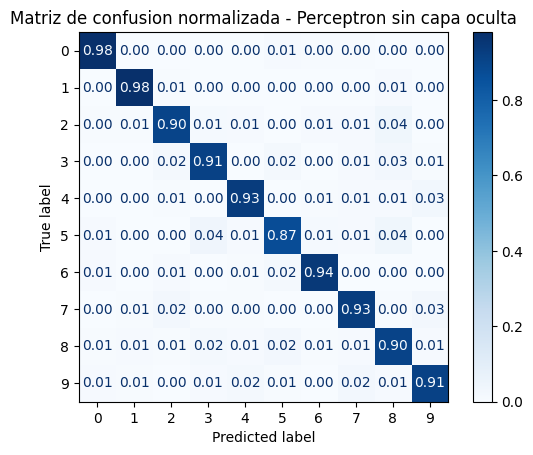

In [ ]:
best_mlp0 = grid_mlp0.best_estimator_
y_pred_test_mlp0 = best_mlp0.predict(X_test)

test_acc_mlp0 = accuracy_score(y_test, y_pred_test_mlp0)
best_idx = grid_mlp0.best_index_
best_train_acc = grid_mlp0.cv_results_["mean_train_score"][best_idx]
best_val_acc = grid_mlp0.best_score_
gap = best_train_acc - best_val_acc

print("Mejores hiperparametros:", grid_mlp0.best_params_)
print(f"Accuracy CV (validacion): {best_val_acc:.4f}")
print(f"Accuracy train (modelo ganador): {best_train_acc:.4f}")
print(f"Brecha train-validacion: {gap:.4f}")
print(f"Accuracy en test: {test_acc_mlp0:.4f}\n")

print("Informe de clasificacion en test:\n")
print(classification_report(y_test, y_pred_test_mlp0, digits=4))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_mlp0,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
)
disp.ax_.set_title("Matriz de confusion normalizada - Perceptron sin capa oculta")



## 4. Perceptrón multicapa

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

base_mlpm = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=80,
    early_stopping=False,
    validation_fraction=0.1,
    n_iter_no_change=8,
    random_state=28,
)

param_dist_mlpm = {
    "mlp__hidden_layer_sizes": [(128,), (256,), (128, 64), (256, 128), (300, 150)],
    "mlp__alpha": [1e-5, 1e-4, 5e-4, 1e-3],
    "mlp__learning_rate_init": [5e-4, 1e-3, 2e-3],
}

cv_mlpm = StratifiedKFold(n_splits=3, shuffle=True, random_state=28)

rs_mlpm = RandomizedSearchCV(
    estimator=Pipeline([("mlp", base_mlpm)]),
    param_distributions=param_dist_mlpm,
    n_iter=12,
    scoring="accuracy",
    cv=cv_mlpm,
    random_state=28,
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

rs_mlpm.fit(X_train, y_train)

cv_results_mlpm = pd.DataFrame({
    "hidden_layers": np.array(rs_mlpm.cv_results_["param_mlp__hidden_layer_sizes"], dtype=str),
    "alpha": np.array(rs_mlpm.cv_results_["param_mlp__alpha"], dtype=float),
    "learning_rate_init": np.array(rs_mlpm.cv_results_["param_mlp__learning_rate_init"], dtype=float),
    "train_accuracy": rs_mlpm.cv_results_["mean_train_score"],
    "val_accuracy": rs_mlpm.cv_results_["mean_test_score"],
})

cv_results_mlpm.sort_values(by="val_accuracy", ascending=False, inplace=True)
cv_results_mlpm.head(10)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [17]:
best_mlpm = rs_mlpm.best_estimator_
y_pred_test_mlpm = best_mlpm.predict(X_test)

test_acc_mlpm = accuracy_score(y_test, y_pred_test_mlpm)
best_idx = rs_mlpm.best_index_
best_train_acc = rs_mlpm.cv_results_["mean_train_score"][best_idx]
best_val_acc = rs_mlpm.best_score_
gap = best_train_acc - best_val_acc

print("Mejores hiperparametros (MLP multicapa):", rs_mlpm.best_params_)
print(f"Accuracy CV (validacion): {best_val_acc:.4f}")
print(f"Accuracy train (modelo ganador): {best_train_acc:.4f}")
print(f"Brecha train-validacion: {gap:.4f}")
print(f"Accuracy en test: {test_acc_mlpm:.4f}\n")

print("Informe de clasificacion en test (MLP multicapa):\n")
print(classification_report(y_test, y_pred_test_mlpm, digits=4))

labels = np.array(rs_mlpm.classes_)
cm_norm = confusion_matrix(y_test, y_pred_test_mlpm, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Matriz de confusion normalizada - Perceptron multicapa")
plt.show()

recalls = np.diag(cm_norm)
worst_idx = np.argsort(recalls)[:3]
print("Digitos mas problematicos (menor recall):")
for i in worst_idx:
    print(f"- Digito {labels[i]}: recall={recalls[i]:.4f}")

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            pairs.append((cm_off[i, j], labels[i], labels[j]))
pairs.sort(key=lambda x: x[0], reverse=True)

print("\nConfusiones mas habituales (porcentaje sobre el digito real):")
for rate, true_label, pred_label in pairs[:8]:
    print(f"- {true_label} -> {pred_label}: {100 * rate:.2f}%")

# Visualizacion de ejemplos reales de la confusion mas frecuente
top_rate, top_true, top_pred = pairs[0]
mask = (y_test == top_true) & (y_pred_test_mlpm == top_pred)
idx = np.where(mask)[0][:12]

if len(idx) > 0:
    fig, axes = plt.subplots(3, 4, figsize=(7, 6))
    for ax, k in zip(axes.ravel(), idx):
        ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r")
        ax.set_title(f"{y_test[k]} -> {y_pred_test_mlpm[k]}")
        ax.axis("off")
    fig.suptitle(f"Ejemplos de la confusion mas habitual: {top_true} -> {top_pred}")
    plt.tight_layout()
    plt.show()

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_estimator_'

## 5. Funciones de evaluacion comunes

Funciones para calcular metricas (`accuracy`, `recall`, `f1`) y mostrar imagenes mal clasificadas (minimo 5 por modelo, si hay al menos 5 errores).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score

def evaluar_modelo_y_errores(
    nombre,
    modelo,
    X_test,
    y_test,
    n_errores=5,
    image_shape=(28, 28),
    random_state=28,
):
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    errores_idx = np.where(y_pred != y_test)[0]
    n_show = min(n_errores, len(errores_idx))

    print(f"\n=== {nombre} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall (macro): {rec:.4f}")
    print(f"F1 (macro): {f1:.4f}")
    print(f"Errores en test: {len(errores_idx)}")

    if len(errores_idx) == 0:
        print("Sin errores de clasificacion en test.")
    else:
        rng = np.random.default_rng(random_state)
        if len(errores_idx) > n_show:
            seleccion = rng.choice(errores_idx, size=n_show, replace=False)
        else:
            seleccion = errores_idx

        if image_shape is None:
            lado = int(np.sqrt(X_test.shape[1]))
            image_shape = (lado, lado)

        cols = min(5, n_show) if n_show > 0 else 1
        rows = int(np.ceil(n_show / cols)) if n_show > 0 else 1
        fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.6 * rows))

        axes = np.array(axes).reshape(-1)
        for ax, idx in zip(axes, seleccion):
            ax.imshow(X_test[idx].reshape(image_shape), cmap="gray_r")
            ax.set_title(f"real={y_test[idx]} / pred={y_pred[idx]}")
            ax.axis("off")

        for ax in axes[len(seleccion):]:
            ax.axis("off")

        fig.suptitle(f"Errores de {nombre} (mostrando {n_show})")
        plt.tight_layout()
        plt.show()

    return {
        "modelo": nombre,
        "accuracy": acc,
        "recall_macro": rec,
        "f1_macro": f1,
        "n_errores_test": int(len(errores_idx)),
    }

def evaluar_modelos(modelos, X_test, y_test, n_errores=5, image_shape=(28, 28), random_state=28):
    resumen = []
    for nombre, modelo in modelos.items():
        fila = evaluar_modelo_y_errores(
            nombre=nombre,
            modelo=modelo,
            X_test=X_test,
            y_test=y_test,
            n_errores=n_errores,
            image_shape=image_shape,
            random_state=random_state,
        )
        resumen.append(fila)

    return pd.DataFrame(resumen).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

In [ ]:
modelos_disponibles = {}

if "grid_reg" in globals() and hasattr(grid_reg, "best_estimator_"):
    modelos_disponibles["Regresion logistica"] = grid_reg.best_estimator_

if "best_mlp0" in globals():
    modelos_disponibles["Perceptron sin capa oculta"] = best_mlp0
elif "grid_mlp0" in globals() and hasattr(grid_mlp0, "best_estimator_"):
    modelos_disponibles["Perceptron sin capa oculta"] = grid_mlp0.best_estimator_

if "best_mlpm" in globals():
    modelos_disponibles["Perceptron multicapa"] = best_mlpm
elif "rs_mlpm" in globals() and hasattr(rs_mlpm, "best_estimator_"):
    modelos_disponibles["Perceptron multicapa"] = rs_mlpm.best_estimator_

if len(modelos_disponibles) == 0:
    print("No hay modelos entrenados disponibles en memoria. Ejecuta primero las secciones 2, 3 y/o 4.")
else:
    resumen_metricas = evaluar_modelos(
        modelos=modelos_disponibles,
        X_test=X_test,
        y_test=y_test,
        n_errores=5,
        image_shape=(28, 28),
        random_state=28,
    )
    print("\nResumen comparativo de metricas:")
    resumen_metricas